In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [4]:
df_test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [5]:
df_train.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [6]:
df_test.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64

In [7]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


In [9]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [10]:
df_train['gender'] = label.fit_transform(df_train['gender'])
df_test['gender'] = label.fit_transform(df_test['gender'])

In [11]:
df_train['marital_status'] = label.fit_transform(df_train['marital_status'])
df_test['marital_status'] = label.fit_transform(df_test['marital_status'])

In [12]:
df_train['education_level'] = label.fit_transform(df_train['education_level'])
df_test['education_level'] = label.fit_transform(df_test['education_level'])

In [14]:
df_train['employment_status'] = label.fit_transform(df_train['employment_status'])
df_test['employment_status'] = label.fit_transform(df_test['employment_status'])

In [15]:
df_train['loan_purpose'] = label.fit_transform(df_train['loan_purpose'])
df_test['loan_purpose'] = label.fit_transform(df_test['loan_purpose'])

In [16]:
df_train['grade_subgrade'] = label.fit_transform(df_train['grade_subgrade'])
df_test['grade_subgrade'] = label.fit_transform(df_test['grade_subgrade'])

In [18]:
X = df_train.drop('loan_paid_back', axis=1)
y = df_train['loan_paid_back']

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
model = DecisionTreeClassifier()

In [22]:
params = {
    'criterion':["gini", "entropy", "log_loss"],
    'splitter': ['best', 'random'],
    'max_depth':[4, 6, 8, 10, 12]
}

In [23]:
final_model = GridSearchCV(model,params,cv = 3,verbose = 2)

In [25]:
X_train = df_train.drop('loan_paid_back', axis=1)
y_train = df_train['loan_paid_back']
X_test = df_test.copy()

In [26]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.5s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.5s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.5s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.8s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.8s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.8s
[CV] END .......criterion=gini, max_depth=6, splitter=random; total time=   0.1s
[CV] END .......criterion=gini, max_depth=6, splitter=random; total time=   0.1s
[CV] END .......criterion=gini, max_depth=6, spl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 6, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [27]:
final_tree = final_model.best_estimator_

In [28]:
final_model.best_params_

{'criterion': 'gini', 'max_depth': 6, 'splitter': 'best'}

In [29]:
from sklearn.tree import plot_tree

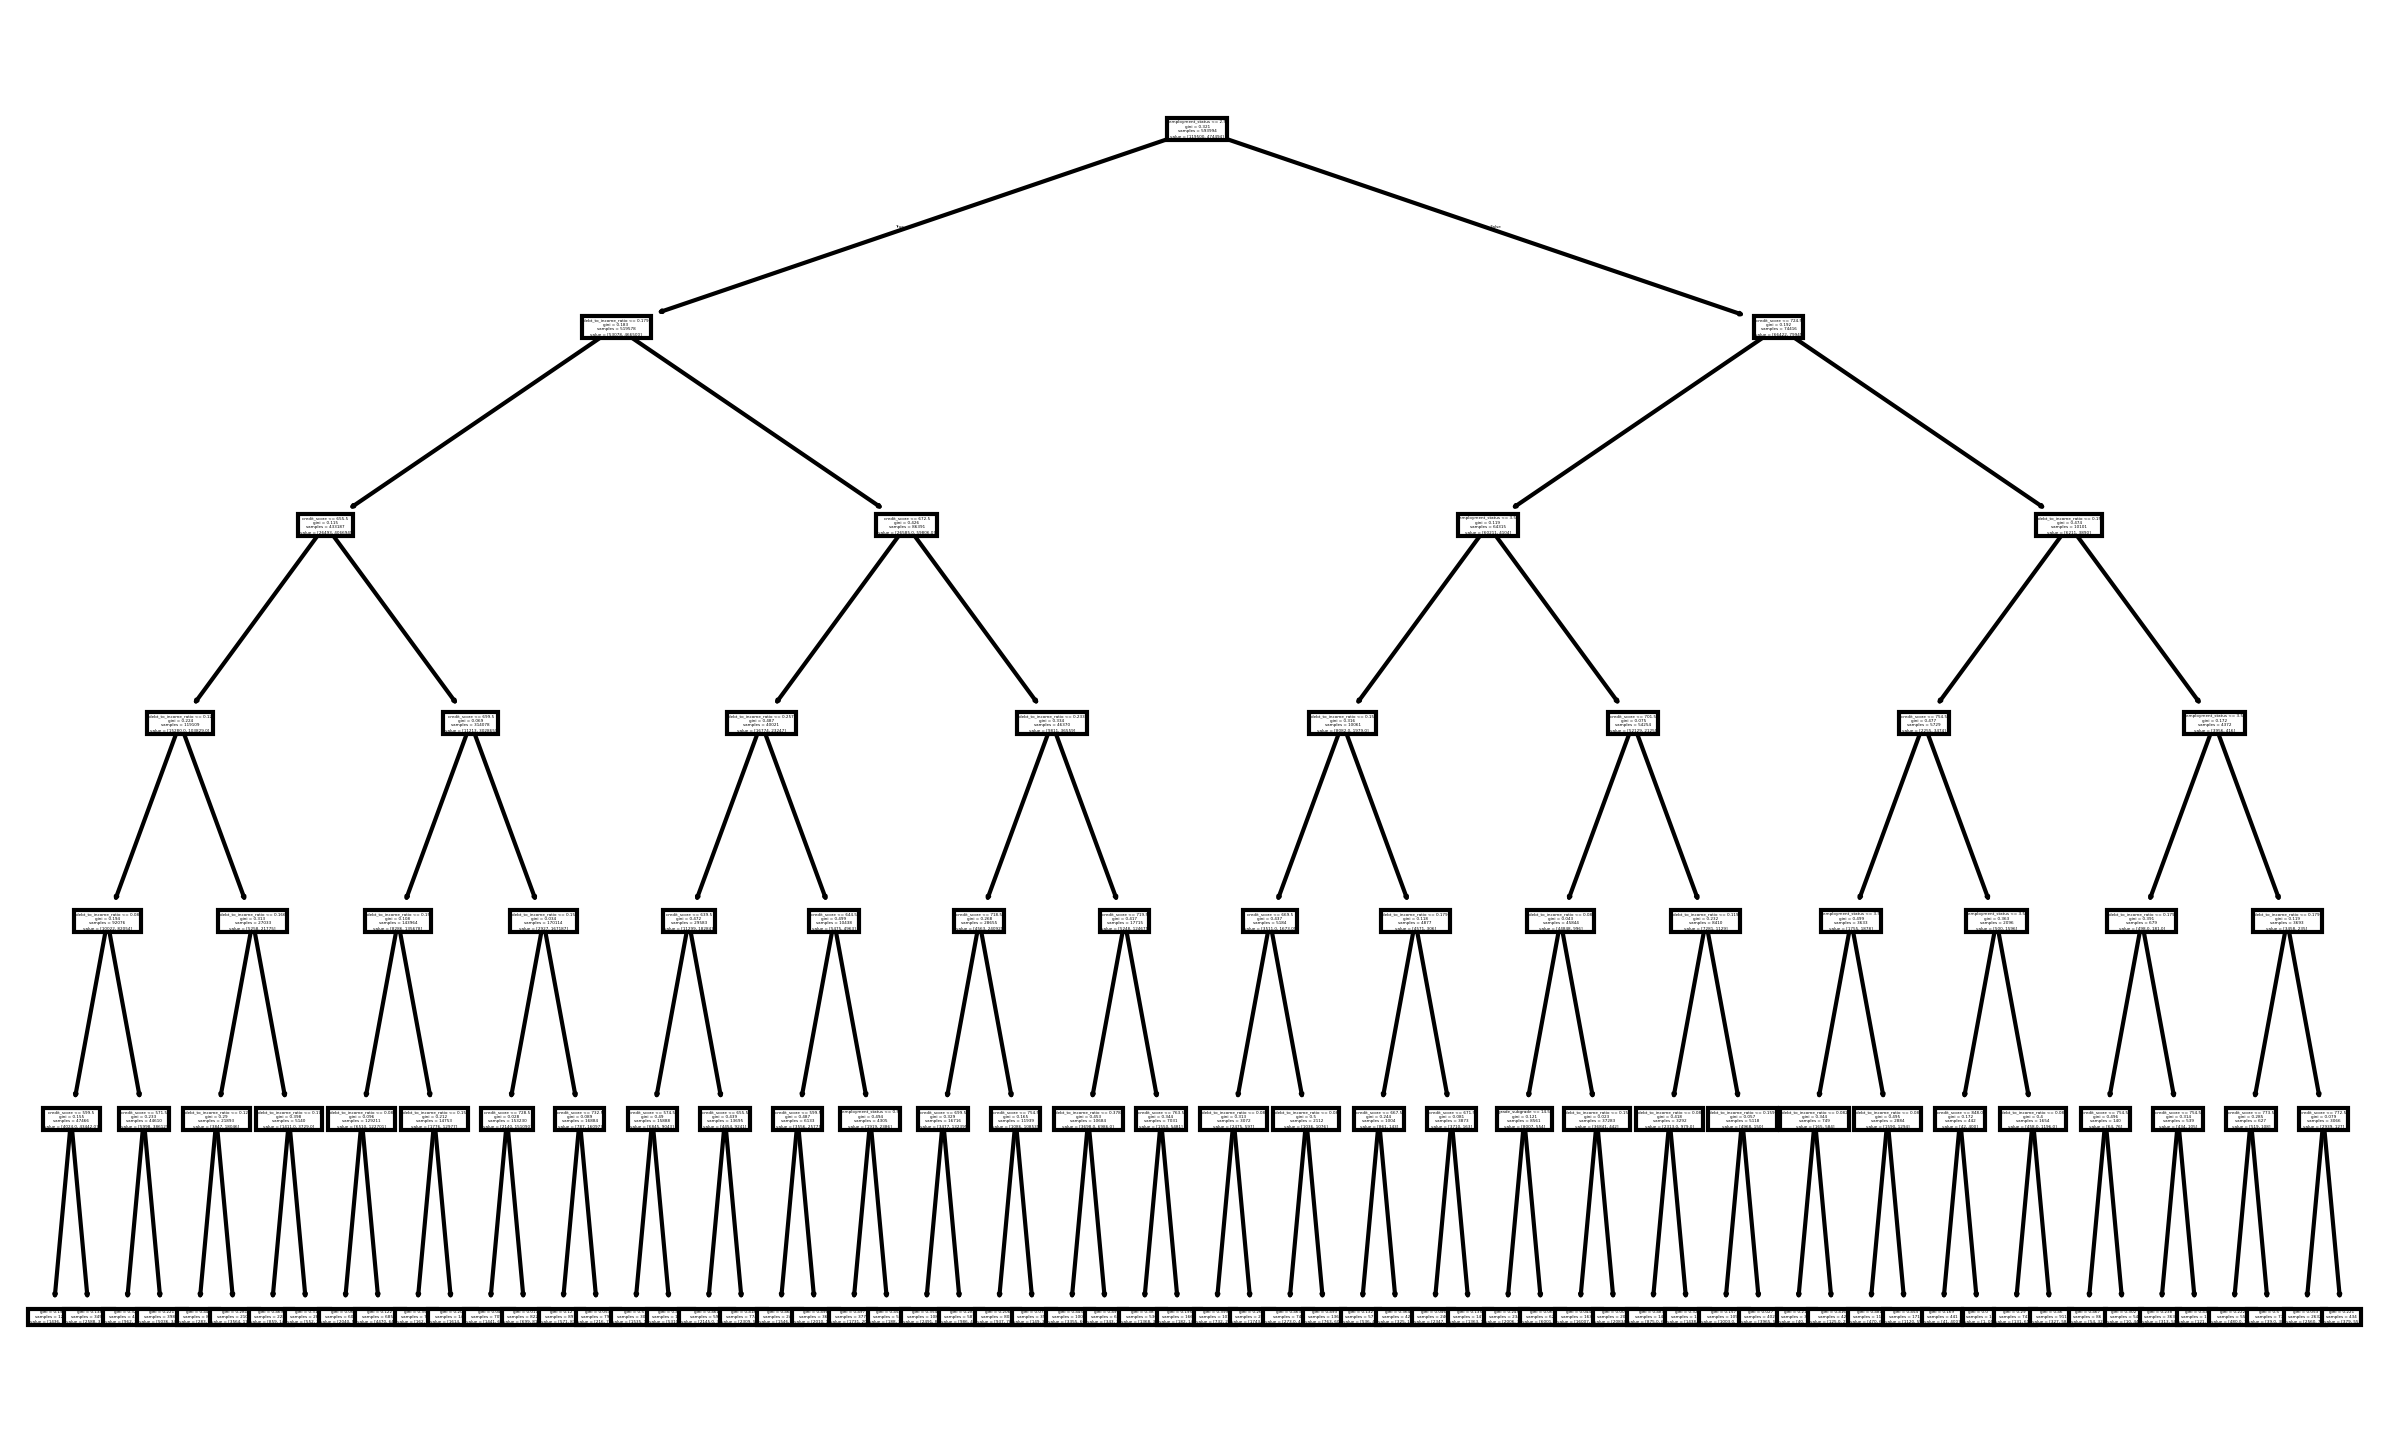

In [30]:
plt.figure(figsize=(10, 6), dpi=300)
plot_tree(final_tree, feature_names=X.columns)
plt.show()

In [31]:
y_pred = final_model.predict(X_test)

In [35]:
df_sub = pd.read_csv('sample_submission.csv')

In [36]:
df_sub['loan_paid_back'] = y_pred

In [37]:
df_sub.to_csv('sub.csv',index = False,index_label=False)

In [38]:
df_sub

,id,loan_paid_back
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0
...,...,...
254564,848558,1.0
254565,848559,1.0
254566,848560,1.0
254567,848561,1.0
